# SOB4ES - Modelo XGBoost
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de inteligencia artificial.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuracion:** Importaciones y parametros globales.
2. **Carga de datos:** Se cargan los tres splits pre-generados.
3. **Tuning:** Busqueda aleatoria de la mejor combinacion de hiperparametros.
4. **Validacion cruzada:** Evaluacion de robustez mediante repeticion de pliegues.
5. **Explicabilidad (SHAP):** Analisis de importancia de variables.
6. **Produccion:** Entrenamiento del ensamble final y exportacion de modelos.
7. **Evaluacion final:** Medicion del rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno
Importaciones y configuracion de rutas y variables globales.

In [8]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

import shap
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold

# ignoramos los warnings
warnings.filterwarnings('ignore')
#os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/xgb'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')

Librerias y variables cargadas correctamente...


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [9]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros del modelo XGBoost. La busqueda se ejecuta exclusivamente sobre `X_train` para evitar cualquier fuga de informacion hacia los splits de validacion y evaluacion.

Como variable objetivo de referencia se usa `earthworm_shannon_z` (lombrices de tierra).


Para combatir el sobreajuste observado (Train R2 ~0.99, Val R2 ~0.47) se aplican tres medidas:
- Grid mas conservador: `max_depth` maximo 4, `n_estimators` maximo 300.
- Regularizacion L1/L2: se añaden `reg_alpha` y `reg_lambda` al grid.
- Early stopping: el entrenamiento para cuando el rendimiento en `X_test` deja de mejorar durante 20 iteraciones consecutivas.


In [10]:
print("Iniciando busqueda de hiperparametros (Tuning)...")
print("Este proceso puede tardar varios minutos.\n")

param_grid = {
    'n_estimators':        [100, 200, 300, 400, 500, 600, 800],
    'max_depth':           [2, 3, 4, 5, 6],
    'learning_rate':       [0.005, 0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
    'subsample':           [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':    [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel':   [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bynode':    [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma':               [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 2.0],
    'min_child_weight':    [1, 2, 3, 5, 7, 10, 15],
    'reg_alpha':           [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0],
    'reg_lambda':          [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0],
    'max_delta_step':      [0, 1, 2, 5],
    'grow_policy':         ['depthwise', 'lossguide'],
    'max_leaves':          [0, 8, 16, 32, 64],
    'scale_pos_weight':    [1.0],
    'tree_method':         ['hist'],
    'random_state':        [42],
}

referencias = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

resultados_tuning = {}

for nombre_target, y_prueba in referencias.items():
    print(f"Buscando hiperparametros para: {nombre_target}")
    buscador = RandomizedSearchCV(
        estimator=XGBRegressor(tree_method='hist', random_state=42),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    start = time.time()
    buscador.fit(X_train, y_prueba)
    elapsed = (time.time() - start) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f"\n  Busqueda completada en {elapsed:.1f} minutos.")
    print(f"  Mejor R2 obtenido: {buscador.best_score_:.4f}")
    print(f"  Hiperparametros optimos: {buscador.best_params_}\n")

# Consenso de hiperparametros 
params_s = resultados_tuning['earthworm_shannon_z']['params']
params_r = resultados_tuning['earthworm_richness_z']['params']
r2_s     = resultados_tuning['earthworm_shannon_z']['r2']
r2_r     = resultados_tuning['earthworm_richness_z']['r2']

w_s = r2_s / (r2_s + r2_r)
w_r = r2_r / (r2_s + r2_r)

print("Calculando consenso de hiperparametros...")
print(f"  Peso earthworm_shannon_z  : {w_s:.3f}")
print(f"  Peso earthworm_richness_z : {w_r:.3f}")

def consenso_int(key, default=None):
    v_s = params_s.get(key, default)
    v_r = params_r.get(key, default)
    return int(round(w_s * v_s + w_r * v_r))

def consenso_float(key, default=None):
    v_s = params_s.get(key, default)
    v_r = params_r.get(key, default)
    return w_s * v_s + w_r * v_r

def consenso_cat(key):
    return params_s[key] if r2_s >= r2_r else params_r[key]

def consenso_log(key):
    v_s = params_s.get(key)
    v_r = params_r.get(key)
    return np.exp(w_s * np.log(v_s) + w_r * np.log(v_r))

XGB_OPTIMAL_PARAMS = {
    'n_estimators':      consenso_int('n_estimators'),
    'max_depth':         consenso_int('max_depth'),
    'learning_rate':     consenso_log('learning_rate'),
    'subsample':         consenso_float('subsample'),
    'colsample_bytree':  consenso_float('colsample_bytree'),
    'colsample_bylevel': consenso_float('colsample_bylevel'),
    'colsample_bynode':  consenso_float('colsample_bynode'),
    'gamma':             consenso_float('gamma', 0.0),
    'min_child_weight':  consenso_int('min_child_weight'),
    'reg_alpha':         consenso_float('reg_alpha', 0.0),
    'reg_lambda':        consenso_float('reg_lambda', 1.0),
    'max_delta_step':    consenso_int('max_delta_step', 0),
    'grow_policy':       consenso_cat('grow_policy'),
    'max_leaves':        consenso_int('max_leaves', 0),
    'tree_method':       'hist',
    'random_state':      42,
}

print("\nHiperparametros consenso finales:")
for k, v in XGB_OPTIMAL_PARAMS.items():
    print(f"  {k}: {v}")

Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos.

Buscando hiperparametros para: earthworm_shannon_z
Fitting 5 folds for each of 150 candidates, totalling 750 fits



  Busqueda completada en 1.6 minutos.
  Mejor R2 obtenido: 0.5011
  Hiperparametros optimos: {'tree_method': 'hist', 'subsample': 0.7, 'scale_pos_weight': 1.0, 'reg_lambda': 10.0, 'reg_alpha': 0.05, 'random_state': 42, 'n_estimators': 500, 'min_child_weight': 5, 'max_leaves': 32, 'max_depth': 6, 'max_delta_step': 0, 'learning_rate': 0.05, 'grow_policy': 'depthwise', 'gamma': 1.0, 'colsample_bytree': 0.7, 'colsample_bynode': 1.0, 'colsample_bylevel': 0.8}

Buscando hiperparametros para: earthworm_richness_z
Fitting 5 folds for each of 150 candidates, totalling 750 fits

  Busqueda completada en 1.5 minutos.
  Mejor R2 obtenido: 0.6065
  Hiperparametros optimos: {'tree_method': 'hist', 'subsample': 1.0, 'scale_pos_weight': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'random_state': 42, 'n_estimators': 300, 'min_child_weight': 15, 'max_leaves': 8, 'max_depth': 5, 'max_delta_step': 0, 'learning_rate': 0.07, 'grow_policy': 'lossguide', 'gamma': 0.0, 'colsample_bytree': 0.7, 'colsample_bynode

## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) aplicada sobre `X_train`. Esto permite detectar sobreajuste comparando el rendimiento en entrenamiento y en los pliegues de validacion.

In [11]:
from sklearn.model_selection import RepeatedKFold

print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

referencias_cv = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

for nombre_target, y_prueba in referencias_cv.items():
    print(f'Target: {nombre_target}')
    print('-' * 55)

    modelo_evaluacion = XGBRegressor(**XGB_OPTIMAL_PARAMS)
    resultados_examen = cross_validate(
        estimator=modelo_evaluacion,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True
    )

    r2_entrenamiento = np.mean(resultados_examen['train_r2'])
    r2_examen_real   = np.mean(resultados_examen['test_r2'])
    r2_desviacion    = np.std(resultados_examen['test_r2'])
    rmse_real        = np.mean(-resultados_examen['test_neg_root_mean_squared_error'])
    mae_real         = np.mean(-resultados_examen['test_neg_mean_absolute_error'])

    print(f'  Train R2          : {r2_entrenamiento:.4f}')
    print(f'  Validacion R2 (CV): {r2_examen_real:.4f} +/- {r2_desviacion:.4f}')
    print(f'  RMSE              : {rmse_real:.4f} puntos de Shannon H\'')
    print(f'  MAE               : {mae_real:.4f} puntos de Shannon H\'')

    diferencia = r2_entrenamiento - r2_examen_real
    if diferencia > 0.15:
        print(f'  Aviso: diferencia train/val = {diferencia:.4f}. Posible sobreajuste.')
    else:
        print(f'  Diferencia train/val = {diferencia:.4f}. El modelo generaliza correctamente.')
    print()

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Target: earthworm_shannon_z
-------------------------------------------------------
  Train R2          : 0.8829
  Validacion R2 (CV): 0.4817 +/- 0.1110
  RMSE              : 0.6933 puntos de Shannon H'
  MAE               : 0.5035 puntos de Shannon H'
  Aviso: diferencia train/val = 0.4012. Posible sobreajuste.

Target: earthworm_richness_z
-------------------------------------------------------
  Train R2          : 0.8969
  Validacion R2 (CV): 0.6101 +/- 0.0377
  RMSE              : 0.6095 puntos de Shannon H'
  MAE               : 0.4585 puntos de Shannon H'
  Aviso: diferencia train/val = 0.2868. Posible sobreajuste.



## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (SHapley Additive exPlanations) para identificar que variables influyen mas en las predicciones del modelo y en que direccion lo hacen.

El grafico de puntos muestra las 10 variables mas importantes:
- Las variables se ordenan de mayor a menor importancia global (de arriba a abajo).
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion (derecha = aumenta el indice, izquierda = lo reduce).

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


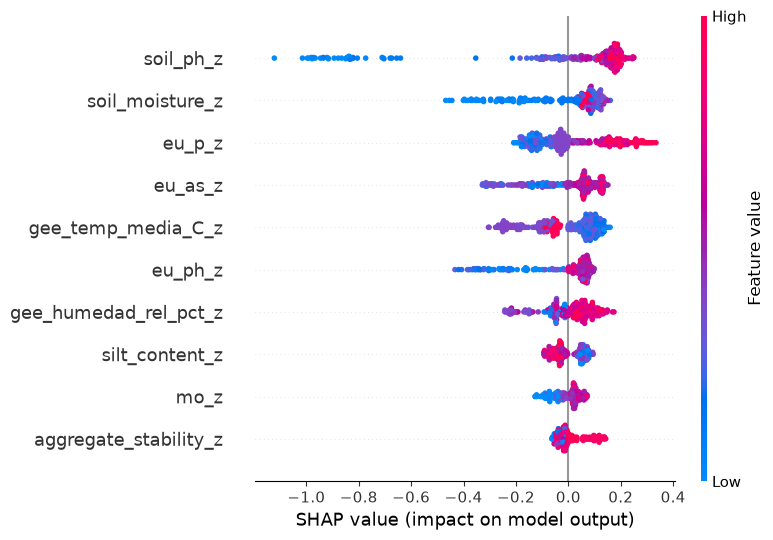

Top 10 variables por importancia SHAP (earthworm_richness_z):


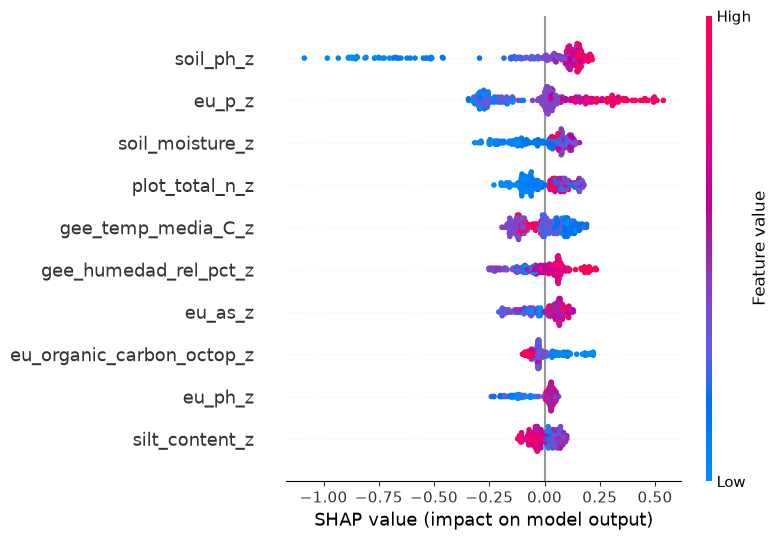

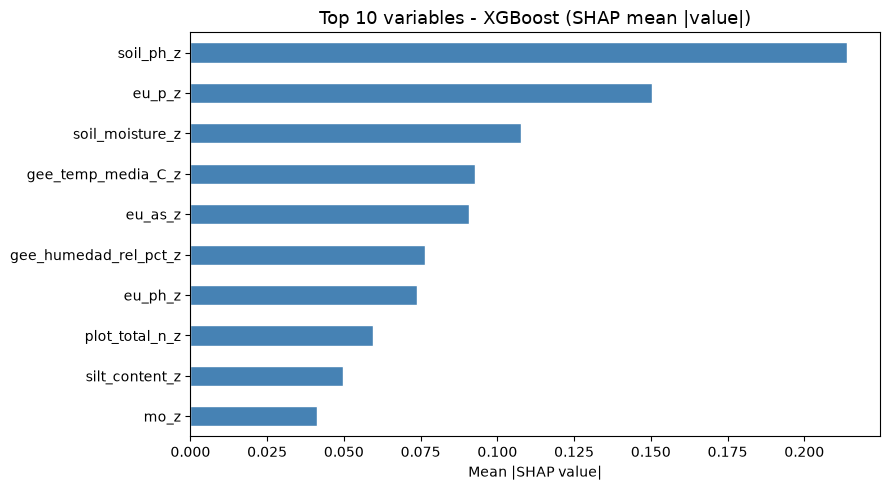

In [12]:
%matplotlib inline

print("Calculando valores SHAP sobre X_train...")

# Shannon

modelo_explicable_shannon = XGBRegressor(**XGB_OPTIMAL_PARAMS)
modelo_explicable_shannon.fit(X_train, y_train['earthworm_shannon_z'].values)

explainer_shannon   = shap.TreeExplainer(modelo_explicable_shannon)
shap_values_shannon = explainer_shannon.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_shannon_z):")
shap.summary_plot(shap_values_shannon, X_train, plot_type="dot", max_display=10)

# Richness
modelo_explicable_richness = XGBRegressor(**XGB_OPTIMAL_PARAMS)
modelo_explicable_richness.fit(X_train, y_train['earthworm_richness_z'].values)

explainer_richness   = shap.TreeExplainer(modelo_explicable_richness)
shap_values_richness = explainer_richness.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_richness_z):")
shap.summary_plot(shap_values_richness, X_train, plot_type="dot", max_display=10)
# Grafico: barplot importancia SHAP media (shannon + richness)
shap_mean = np.mean([
    np.abs(shap_values_shannon),
    np.abs(shap_values_richness)
], axis=0).mean(axis=0)

shap_importance = pd.Series(shap_mean, index=FEATURES_AUTORIZADAS).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 variables - XGBoost (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

## 6.- Entrenamiento de produccion

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria en cada uno. Esto reduce la varianza de las predicciones y mejora la robustez en produccion.

Todos los modelos se entrenan sobre `X_train` y se guardan en disco en formato `.pkl`.

In [13]:
print("Entrenamiento de produccion (ensamble de 5 modelos por target)...")
print("-" * 70)

global_start_time = time.time()
NUM_EXPERTOS = 5

for idx, target_col in enumerate(TARGETS, 1):
    target_start_time = time.time()
    y = y_train[target_col].values

    for experto_id in range(NUM_EXPERTOS):
        parametros_experto = XGB_OPTIMAL_PARAMS.copy()
        parametros_experto['random_state'] = 42 + experto_id

        model = XGBRegressor(**parametros_experto)
        model.fit(X_train, y)

        pkl_path = os.path.join(MODELS_DIR, f"xgb_prod_{target_col}_exp{experto_id}.pkl")
        joblib.dump(model, pkl_path)

    elapsed = time.time() - target_start_time
    print(f"  [{idx}/{len(TARGETS)}] {target_col:30} completado ({elapsed:.1f}s)")

print("-" * 70)
print(f"Produccion completada en {(time.time() - global_start_time)/60:.1f} minutos.")
print(f"Modelos guardados: {len(TARGETS) * NUM_EXPERTOS} ({NUM_EXPERTOS} por target).")

Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------
  [1/21] nematode_shannon_z             completado (1.9s)
  [2/21] macro_shannon_z                completado (2.1s)
  [3/21] earthworm_shannon_z            completado (1.9s)
  [4/21] orib_shannon_z                 completado (2.0s)
  [5/21] meso_shannon_z                 completado (2.1s)
  [6/21] coll_shannon_z                 completado (2.4s)
  [7/21] bac_shannon_z                  completado (4.5s)
  [8/21] fun_shannon_z                  completado (2.6s)
  [9/21] euk_shannon_z                  completado (2.3s)
  [10/21] oomy_shannon_z                 completado (2.3s)
  [11/21] cerc_shannon_z                 completado (3.0s)
  [12/21] macro_order_richness_z         completado (2.2s)
  [13/21] earthworm_richness_z           completado (1.8s)
  [14/21] orib_species_richness_z        completado (2.1s)
  [15/21] meso_species_richness_z        compl

## 7.- Evaluacion final sobre eval.csv

Por primera vez se usa `eval.csv`: el dataset que el modelo no ha visto en ningun momento anterior. Esto proporciona una estimacion real e imparcial del rendimiento en produccion.

Ademas se ejecuta una comprobacion de funcionamiento completo del pipeline (smoke test): se carga el ensamble desde disco, se predice sobre datos nuevos y se verifica que la inferencia por consenso funciona correctamente.

**Interpretacion del indice Shannon H':**  
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica). Un valor bajo indica un suelo poco diverso; un valor alto, un suelo biologicamente rico.

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.2427   0.8594   0.6680
  macro_shannon_z                  0.4012   0.7772   0.6247
  earthworm_shannon_z              0.5274   0.6862   0.4657
  orib_shannon_z                   0.2495   0.9907   0.8090
  meso_shannon_z                  -0.2571   1.0949   0.8730
  coll_shannon_z                  -0.3925   0.7476   0.5749
  bac_shannon_z                   -0.0591   1.0305   0.6984
  fun_shannon_z                   -0.0349   1.1639   0.9292
  euk_shannon_z                    0.0894   0.9254   0.6556
  oomy_shannon_z                   0.0119   1.0391   0.7590
  cerc_shannon_z                  -0.0166   0.9029   0.6495
  macro_order_richness_z           0.4133   0.7015   0.5651
  earthworm_richness_z             0.6020   0.5761   0.4

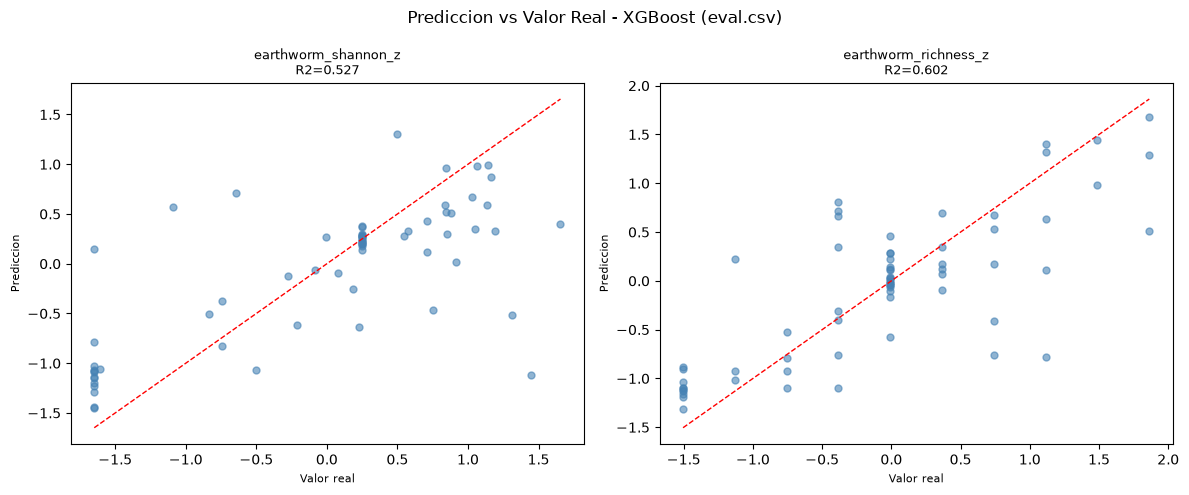

In [14]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

NUM_EXPERTOS = 5

# Evaluacion final sobre todos los targets
# Usamos eval.csv, que el modelo no ha visto hasta ahora.

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    # Cargamos los 5 modelos del target actual y promediamos sus predicciones
    preds_eval = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)


# Smoke test con datos reales
# Se prueba sobre dos targets representativos: uno shannon y uno richness.

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    # Tomamos 3 filas reales al azar del dataset de evaluacion
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)

        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        # Cada uno de los 5 modelos vota con su propia prediccion para las 3 parcelas
        votos = []
        for experto_id in range(NUM_EXPERTOS):
            ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {experto_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        # Promediamos los 5 votos para obtener la prediccion final de consenso
        consenso = np.mean(votos, axis=0)

        print('  ' + '-' * 63)
        print('  Resultados detallados por muestra evaluada:')
        print('  ' + '-' * 63)

        for i, idx_muestra in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx_muestra:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('\nSmoke test superado. El pipeline de XGBoost funciona y predice con coherencia.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['earthworm_shannon_z', 'earthworm_richness_z']):
    preds = [joblib.load(os.path.join(MODELS_DIR, f'xgb_prod_{tgt}_exp{i}.pkl')).predict(X_eval)
             for i in range(NUM_EXPERTOS)]
    yp = np.mean(preds, axis=0)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.6, s=25, color='steelblue')
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - XGBoost (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()